### Task IV: Quantum Generative Adversarial Network (QGAN)
You will explore how best to apply a quantum generative adversarial network (QGAN) to solve a High Energy Data analysis issue, more specifically, separating the signal events from the background events. You should use the Google Cirq and Tensorflow Quantum (TFQ) libraries for this task.

A set of input samples (simulated with Delphes) is provided in NumPy NPZ format [Download Input]. In the input file, there are only 100 samples for training and 100 samples for testing so it won’t take much computing resources to accomplish this
task. The signal events are labeled with 1 while the background events are labeled with 0.

Be sure to show that you understand how to fine tune your machine learning model to improve the performance. The performance can be evaluated with classification accuracy or Area Under ROC Curve (AUC).


In [ ]:
!pip install tensorflow_quantum

In [ ]:
!pip install cirq

In [3]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"

Data Loaded. Original shape: (50, 5), Post-PCA shape: (50, 3)
Starting training...
Step 0/50: D_loss=0.172, G_loss=-0.262
Step 25/50: D_loss=0.158, G_loss=-0.419

Evaluating final performance...
------------------------------
FINAL ACCURACY: 0.7200
FINAL AUC SCORE: 0.4400
------------------------------


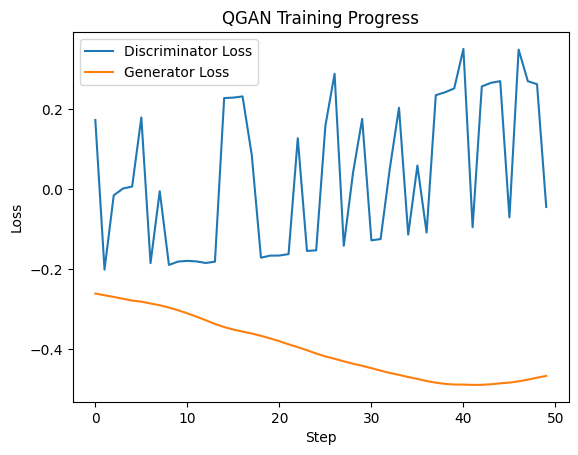

In [16]:
import cirq, sympy, tensorflow as tf, tensorflow_quantum as tfq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, roc_auc_score

# -------------------------
# 1. Load and Preprocess Data
# -------------------------
# Load the specific 200-event dataset
data = np.load("/content/QIS_EXAM_200Events.npz", allow_pickle=True)
train_raw = data["training_input"].item()
X_train_5d = train_raw['1']  # Original data with 5 parameters

# Apply PCA to reduce dimensions from 5 to 3 for the quantum circuit
pca = PCA(n_components=3)
X_train_3d = pca.fit_transform(X_train_5d)

print(f"Data Loaded. Original shape: {X_train_5d.shape}, Post-PCA shape: {X_train_3d.shape}")

# -------------------------
# 2. Define Qubits and Symbols
# -------------------------
q0, q1, q2 = cirq.LineQubit.range(3)

# Symbols for the 3 PCA-reduced parameters
phi0, phi1, phi2 = sympy.symbols('phi0 phi1 phi2')
# Weights for Generator and Discriminator (9 each)
gen_w = sympy.symbols('g0:9')
disc_w = sympy.symbols('d0:9')

# -------------------------
# 3. Build Circuits
# -------------------------
def build_real_circuit():
    """Real circuit strictly using the 3 PCA-derived parameters."""
    return cirq.Circuit([
        cirq.H(q0),
        cirq.rz(phi0)(q0),
        cirq.ry(phi1)(q0),
        cirq.rz(phi2)(q0)
    ])

def build_generator():
    """Quantum Generator circuit."""
    return cirq.Circuit([
        cirq.H(q0),
        cirq.rx(gen_w[0])(q0), cirq.rx(gen_w[1])(q1),
        cirq.ry(gen_w[2])(q0), cirq.ry(gen_w[3])(q1),
        cirq.rz(gen_w[4])(q0), cirq.rz(gen_w[5])(q1),
        cirq.CNOT(q0, q1),
        cirq.rx(gen_w[6])(q0), cirq.ry(gen_w[7])(q0), cirq.rz(gen_w[8])(q0)
    ])

def build_discriminator():
    """Quantum Discriminator circuit."""
    return cirq.Circuit([
        cirq.H(q0),
        cirq.rx(disc_w[0])(q0), cirq.rx(disc_w[1])(q2),
        cirq.ry(disc_w[2])(q0), cirq.ry(disc_w[3])(q2),
        cirq.rz(disc_w[4])(q0), cirq.rz(disc_w[5])(q2),
        cirq.CNOT(q0, q2),
        cirq.rx(disc_w[6])(q2), cirq.ry(disc_w[7])(q2), cirq.rz(disc_w[8])(q2)
    ])

# -------------------------
# 4. TFQ Tensors and Ops
# -------------------------
real_disc_circuit = build_real_circuit() + build_discriminator()
gen_disc_circuit = build_generator() + build_discriminator()

real_disc_tensor = tfq.convert_to_tensor([real_disc_circuit])
gen_disc_tensor = tfq.convert_to_tensor([gen_disc_circuit])

observable = cirq.Z(q2)
expectation_layer = tfq.layers.Expectation()

# -------------------------
# 5. Helper Probabilities
# -------------------------
def prob_real_true(phi_vals, d_weights):
    """Discriminator score for real data (Expectation mapped to [0,1])."""
    return (expectation_layer(
        real_disc_tensor,
        symbol_names=[str(phi0), str(phi1), str(phi2)] + [str(x) for x in disc_w],
        symbol_values=tf.concat([tf.reshape(phi_vals, (1,3)), tf.reshape(d_weights, (1,9))], axis=1),
        operators=observable
    ) + 1) / 2

def prob_fake_true(g_weights, d_weights):
    """Discriminator score for generated data (Expectation mapped to [0,1])."""
    return (expectation_layer(
        gen_disc_tensor,
        symbol_names=[str(x) for x in gen_w] + [str(x) for x in disc_w],
        symbol_values=tf.concat([tf.reshape(g_weights, (1,9)), tf.reshape(d_weights, (1,9))], axis=1),
        operators=observable
    ) + 1) / 2

# -------------------------
# 6. Training Loop
# -------------------------
gen_weights = tf.Variable(tf.random.uniform([9]))
disc_weights = tf.Variable(tf.random.uniform([9]))

opt_disc = tf.keras.optimizers.Adam(learning_rate=0.01)
opt_gen  = tf.keras.optimizers.Adam(learning_rate=0.01)

d_losses, g_losses = [], []

print("Starting training...")
for step in range(len(X_train_3d)):
    phi_input = tf.constant(X_train_3d[step], dtype=tf.float32)

    # Train Discriminator
    with tf.GradientTape() as tape:
        p_real = prob_real_true(phi_input, disc_weights)
        p_fake = prob_fake_true(gen_weights, disc_weights)
        d_loss = p_fake - p_real # Disc wants p_real=1, p_fake=0
    d_grads = tape.gradient(d_loss, [disc_weights])
    opt_disc.apply_gradients(zip(d_grads, [disc_weights]))

    # Train Generator
    with tf.GradientTape() as tape:
        p_fake = prob_fake_true(gen_weights, disc_weights)
        g_loss = -p_fake # Gen wants p_fake=1
    g_grads = tape.gradient(g_loss, [gen_weights])
    opt_gen.apply_gradients(zip(g_grads, [gen_weights]))

    d_losses.append(d_loss.numpy().item())
    g_losses.append(g_loss.numpy().item())

    if step % 25 == 0:
        print(f"Step {step}/{len(X_train_3d)}: D_loss={d_losses[-1]:.3f}, G_loss={g_losses[-1]:.3f}")

# -------------------------
# 7. Final Evaluation: Accuracy and AUC
# -------------------------
real_scores, fake_scores = [], []

print("\nEvaluating final performance...")
for i in range(len(X_train_3d)):
    phi_val = tf.constant(X_train_3d[i], dtype=tf.float32)
    real_scores.append(prob_real_true(phi_val, disc_weights).numpy().flatten()[0])
    fake_scores.append(prob_fake_true(gen_weights, disc_weights).numpy().flatten()[0])

# Combine results for classification metrics
y_true = np.array([1] * len(real_scores) + [0] * len(fake_scores))
y_probs = np.array(real_scores + fake_scores)
y_pred = np.where(y_probs > 0.5, 1, 0)

final_acc = accuracy_score(y_true, y_pred)
final_auc = roc_auc_score(y_true, y_probs)

print("-" * 30)
print(f"FINAL ACCURACY: {final_acc:.4f}")
print(f"FINAL AUC SCORE: {final_auc:.4f}")
print("-" * 30)

# -------------------------
# 8. Plot Losses
# -------------------------
plt.plot(d_losses, label="Discriminator Loss")
plt.plot(g_losses, label="Generator Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("QGAN Training Progress")
plt.legend()
plt.show()